In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.insert(0, "..")   

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
df = pd.read_excel(
    "../data/CP_Full_PT_List_June2025_Updated_July2025_Vision_Collection_Yves_Highlight.xlsx",
    sheet_name='Craniopharyngioma',  
    index_col=1,
    header=0  # This explicitly uses the first row (index 0) as the header
)
df.head()

,Patient_Num,Preop_Visual_Field_Deficit,Preop_VIS_Score,Sex_Male,Race,Age_at_Surgery_Years,MFI5,MFI11,CCI,EEA,EOR,Postop_Visual_Field_Deficit,Postop_VIS_Score,Patient_Reported_Postop_Visual_Outcome,Neurosurgeon_Postop_Visual_Outcome
Patient_MRN,,,,,,,,,,,,,,,
JH44217262,4,0.0,0.0,1,White,24.15,0,0,2,0,3,0.0,0.0,Unchanged,Unchanged
JH52435303,6,NaN,NaN,1,White,72.38,0,0,5,0,2,NaN,NaN,Unchanged,Unchanged
JH44462658,7,1.0,16.0,0,White,34.90,0,0,2,1,3,0.0,0.0,Improved,Improved
JH52717814,9,NaN,NaN,1,White,39.67,1,1,2,0,1,NaN,NaN,Worsened,NaN
JH54720118,12,0.0,NaN,1,White,41.53,0,0,3,0,3,1.0,22.0,Unchanged,Unchanged


In [5]:
df.columns

Index(['Patient_Num', 'Preop_Visual_Field_Deficit', 'Preop_VIS_Score',
       'Sex_Male', 'Race', 'Age_at_Surgery_Years', 'MFI5', 'MFI11', 'CCI',
       'EEA', 'EOR', 'Postop_Visual_Field_Deficit', 'Postop_VIS_Score',
       'Patient_Reported_Postop_Visual_Outcome',
       'Neurosurgeon_Postop_Visual_Outcome'],
      dtype='object')

In [8]:
df[["Sex_Male", "Race", "Age_at_Surgery_Years"]]

,Sex_Male,Race,Age_at_Surgery_Years
Patient_MRN,,,
JH44217262,1,White,24.15
JH52435303,1,White,72.38
JH44462658,0,White,34.90
JH52717814,1,White,39.67
JH54720118,1,White,41.53
...,...,...,...
JH69158800,1,Black or African American,10.85
JH39188745,1,White,61.58
JH39300721,1,White,37.85


In [12]:

# 1. Calculate Descriptive Statistics
# Group by Sex (0=Female, 1=Male) and calculate Count, Mean, and Standard Deviation
summary_df = df.groupby('Sex_Male')['Age_at_Surgery_Years'].agg(['count', 'mean', 'std']).reset_index()

# Map 0/1 to Female/Male for clarity
summary_df['Group'] = summary_df['Sex_Male'].map({0: 'Female', 1: 'Male'})

# Rename columns for the final report
summary_df = summary_df[['Group', 'count', 'mean', 'std']]
summary_df.columns = ['Group', 'N', 'Mean_Age', 'Std_Dev_Age']

# 2. Perform the T-Test
male_ages = df[df['Sex_Male'] == 1]['Age_at_Surgery_Years']
female_ages = df[df['Sex_Male'] == 0]['Age_at_Surgery_Years']

# Calculate p-value (Welch's t-test)
t_stat, p_val = stats.ttest_ind(male_ages, female_ages, equal_var=False)

# 3. Add P-value to the DataFrame
# We add the p-value to the dataframe (same value for both rows since it's one comparison)
summary_df['P_Value_Ttest'] = p_val
summary_df.to_csv('../output/metrics/age_sex_stats_summary.csv', index=False)
summary_df

,Group,N,Mean_Age,Std_Dev_Age,P_Value_Ttest
0,Female,35,39.135143,23.449588,0.510113
1,Male,48,42.517500,22.337386,0.510113


In [13]:
cols= ['Preop_Visual_Field_Deficit', 'Preop_VIS_Score',
       'MFI5', 'MFI11', 'CCI',
       'EEA', 'EOR', 
       'Postop_Visual_Field_Deficit', 
       'Postop_VIS_Score',
       'Neurosurgeon_Postop_Visual_Outcome']
df[cols]

,Preop_Visual_Field_Deficit,Preop_VIS_Score,MFI5,MFI11,CCI,EEA,EOR,Postop_Visual_Field_Deficit,Postop_VIS_Score,Neurosurgeon_Postop_Visual_Outcome
Patient_MRN,,,,,,,,,,
JH44217262,0.0,0.0,0,0,2,0,3,0.0,0.0,Unchanged
JH52435303,NaN,NaN,0,0,5,0,2,NaN,NaN,Unchanged
JH44462658,1.0,16.0,0,0,2,1,3,0.0,0.0,Improved
JH52717814,NaN,NaN,1,1,2,0,1,NaN,NaN,NaN
JH54720118,0.0,NaN,0,0,3,0,3,1.0,22.0,Unchanged
...,...,...,...,...,...,...,...,...,...,...
JH69158800,0.0,0.0,1,1,5,0,3,0.0,0.0,Improved
JH39188745,NaN,NaN,0,0,4,1,3,NaN,NaN,Improved
JH39300721,NaN,NaN,0,1,2,1,2,NaN,NaN,Improved


In [ ]:

# Assuming 'df' is your dataframe
# ... (Load your data here) ...

# --- Helper Function for Categorical Stats ---
def get_categorical_stats(df, columns):
    frames = []
    for col in columns:
        # Get counts and percentages
        counts = df[col].value_counts(dropna=False).sort_index()
        percents = df[col].value_counts(dropna=False, normalize=True).sort_index() * 100
        
        # Format into a clean table
        temp_df = pd.DataFrame({
            'Level': counts.index,
            'Count': counts.values,
            'Percentage': percents.values
        })
        temp_df['Variable'] = col
        frames.append(temp_df[['Variable', 'Level', 'Count', 'Percentage']])
    
    if frames:
        return pd.concat(frames, ignore_index=True)
    return pd.DataFrame()

# ---------------------------------------------------------
# 1. VIS Scores (Continuous) -> Mean, SD, Median
# ---------------------------------------------------------
vis_cols = ['Preop_VIS_Score', 'Postop_VIS_Score']

# Describe gives count, mean, std, min, 25%, 50%, 75%, max
vis_stats = df[vis_cols].describe().T[['count', 'mean', 'std', '50%']]
vis_stats.columns = ['N', 'Mean', 'Std_Dev', 'Median']
vis_stats.index.name = 'Variable'
vis_stats = vis_stats.reset_index().round(2)

print("--- 1. Vis Scores Stats ---")
print(vis_stats)
vis_stats.to_csv('../output/metrics/stats_1_vis_scores.csv', index=False)


# ---------------------------------------------------------
# 2. Categorical Group (MFI, CCI, EOR) -> Count, %
# ---------------------------------------------------------
cat_cols = ['MFI5', 'MFI11', 'CCI', 'EOR']
cat_stats = get_categorical_stats(df, cat_cols).round(2)

print("\n--- 2. Categorical Stats (MFI, CCI, EOR) ---")
print(cat_stats)
cat_stats.to_csv('../output/metrics/stats_2_mfi_cci_eor.csv', index=False)


# ---------------------------------------------------------
# 3. EEA (Binary) -> Count, %
# ---------------------------------------------------------
eea_stats = get_categorical_stats(df, ['EEA']).round(2)

print("\n--- 3. EEA Stats ---")
print(eea_stats)
eea_stats.to_csv('../output/metrics/stats_3_eea.csv', index=False)


# ---------------------------------------------------------
# 4. Outcome -> Count, %
# ---------------------------------------------------------
outcome_stats = get_categorical_stats(df, ['Neurosurgeon_Postop_Visual_Outcome']).round(2)

print("\n--- 4. Outcome Stats ---")
print(outcome_stats)
outcome_stats.to_csv('../output/metrics/stats_4_outcome.csv', index=False)

--- 1. Vis Scores Stats ---
           Variable     N   Mean  Std_Dev  Median
0   Preop_VIS_Score  36.0  28.25    28.56    23.5
1  Postop_VIS_Score  50.0  22.60    23.72    17.0

--- 2. Categorical Stats (MFI, CCI, EOR) ---
   Variable  Level  Count  Percentage
0      MFI5      0     51       61.45
1      MFI5      1     26       31.33
2      MFI5      2      5        6.02
3      MFI5      3      1        1.20
4     MFI11      0     47       56.63
5     MFI11      1     24       28.92
6     MFI11      2      6        7.23
7     MFI11      3      5        6.02
8     MFI11      4      1        1.20
9       CCI      2     36       43.37
10      CCI      3     10       12.05
11      CCI      4     19       22.89
12      CCI      5      6        7.23
13      CCI      6      7        8.43
14      CCI      7      4        4.82
15      CCI      8      1        1.20
16      EOR      1     21       25.30
17      EOR      2     22       26.51
18      EOR      3     40       48.19

--- 3. EEA Stat

In [9]:
df["Neurosurgeon_Postop_Visual_Outcome"].value_counts()

Neurosurgeon_Postop_Visual_Outcome
Improved     40
Unchanged    28
Worsened     10
Name: count, dtype: int64

In [5]:
cols = ['Preop_Visual_Field_Deficit', 'Preop_VIS_Score',
       'Sex_Male', 'Race', 'Age_at_Surgery_Years', 'MFI5', 'MFI11', 'CCI',
       'EEA', 'EOR']
df = df[cols]
df.reset_index(inplace=True)

In [4]:
df.head()

,Patient_MRN,Preop_Visual_Field_Deficit,Preop_VIS_Score,Sex_Male,Race,Age_at_Surgery_Years,MFI5,MFI11,CCI,EEA,EOR
0,JH44217262,0.0,0.0,1,White,24.15,0,0,2,0,3
1,JH52435303,NaN,NaN,1,White,72.38,0,0,5,0,2
2,JH44462658,1.0,16.0,0,White,34.90,0,0,2,1,3
3,JH52717814,NaN,NaN,1,White,39.67,1,1,2,0,1
4,JH54720118,0.0,NaN,1,White,41.53,0,0,3,0,3


In [10]:
path="../data/processed_vision_data.csv"
df = pd.read_csv(path)
df.head()

,Patient_Num,JHH_Surgery_Bin,Path_CP_Confirmation,Updated (10/16/2025),Pre-op_NSGY_Deficit,Pre-Op_Visual_Acuity_R_Eye,Pre-Op_Visual_Acuity_L_Eye,preop_acuity_deficit (worse than 20/40 in one eye),VIS_preop_acuity,Preop_Humphrey_24-2_Goldmann,...,Post-Op_Visual_Acuity_L_Eye_encoded,Post-Op_Visual_Field_R_Eye_encoded,Post-Op_Visual_Field_L_Eye_encoded,PT_Vision_Subjective_Opth_encoded,NSGY_Postop_Subjective_Description_encoded,Unnamed: 30_encoded,field_improvement_binary,field_improvement_score,acuity_improvement_binary,logmar_improvement_score
0,4,1,1,1.0,0,20,20,0.0,0.0,2024-12-16,...,12,9,7,4,1,2,0,0.0,0,NaN
1,12,1,1,1.0,1,Unknown,Unknown,NaN,NaN,NaN,...,4,3,5,4,1,2,0,NaN,0,NaN
2,97,1,1,1.0,Visual fields are reasonably good to confronta...,Unknown,Unknown,NaN,NaN,NaN,...,15,24,24,4,4,2,0,NaN,0,NaN
3,133,1,1,1.0,0,Unknown,Unknown,NaN,NaN,NaN,...,15,9,7,4,27,2,0,NaN,0,NaN
4,198,1,1,1.0,Bitemporal hemianopsia,25,30,0.0,8.0,2016-09-23,...,2,14,17,0,27,2,1,23.0,1,5.0


In [5]:
df.drop(columns=["ts_first", "ts_last", "src_file"], inplace=True)

In [6]:
df.dtypes

epoch                int64
epoch_time_sec     float64
lr                 float64
train_loss         float64
val_loss           float64
WholeTumor_Dice    float64
TumorCore_Dice     float64
Enhancing_Dice     float64
EMA_DICE           float64
dtype: object

In [7]:
df

,epoch,epoch_time_sec,lr,train_loss,val_loss,WholeTumor_Dice,TumorCore_Dice,Enhancing_Dice,EMA_DICE
0,0,499.14,0.01000,-0.4202,-0.6731,0.8372,0.7485,0.7854,0.7904
1,1,367.48,0.00999,-0.7489,-0.7546,0.8889,0.8004,0.8066,0.7945
2,2,360.84,0.00998,-0.7978,-0.7694,0.8955,0.8002,0.8042,0.7984
3,3,363.43,0.00997,-0.8237,-0.7835,0.8981,0.8134,0.8097,0.8026
4,4,384.53,0.00996,-0.8361,-0.7918,0.9040,0.8166,0.8016,0.8064
...,...,...,...,...,...,...,...,...,...
995,995,369.23,0.00008,-0.9489,-0.8129,0.9173,0.8609,0.8070,NaN
996,996,374.11,0.00007,-0.9483,-0.8118,0.9223,0.8581,0.8035,NaN
997,997,376.27,0.00005,-0.9488,-0.8225,0.9224,0.8635,0.8073,NaN
998,998,364.63,0.00004,-0.9490,-0.8144,0.9201,0.8661,0.8198,NaN


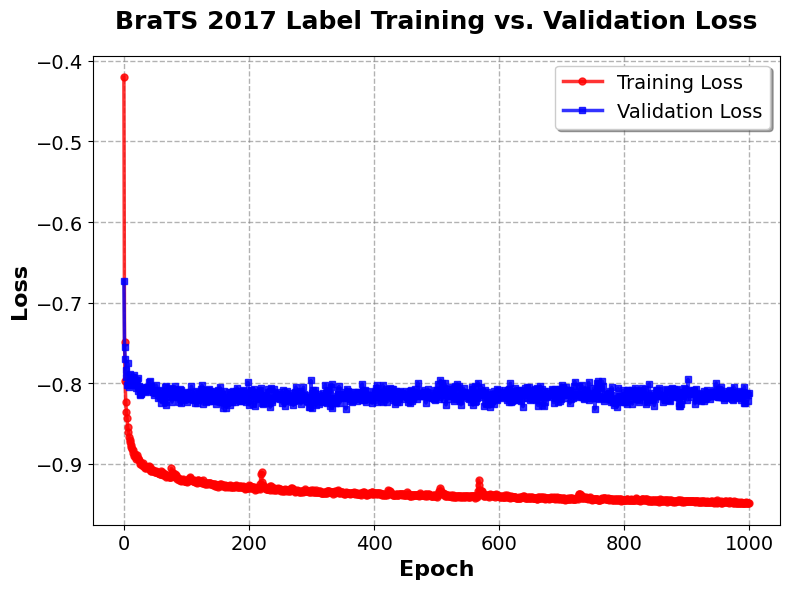

In [10]:
# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Combined plot with both training and validation loss
ax.plot(df["epoch"], df["train_loss"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='Training Loss', alpha=0.8)
ax.plot(df["epoch"], df["val_loss"], 'b-', linewidth=2.5, marker='s', 
        markersize=5, label='Validation Loss', alpha=0.8)

# Styling
ax.set_title("BraTS 2017 Label Training vs. Validation Loss", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("Loss", fontsize=16, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# White background and more visible grid
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.6, linestyle='--', linewidth=1, color='gray')
ax.set_axisbelow(True)  # Put grid behind the plot lines

plt.tight_layout()
#fn = Path("../output/figures/nnunet_brats2017_501_loss_fold0_plot.tiff")
#plt.savefig(fn, dpi=300)
plt.show()
plt.close()

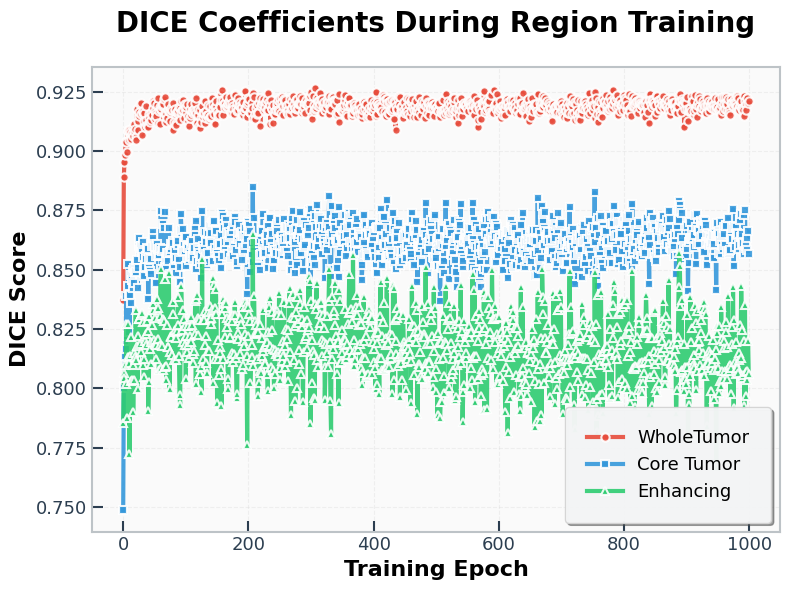

In [16]:

# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors and markers
colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green
markers = ['o', 's', '^']
labels = ['WholeTumor', 'Core Tumor', 'Enhancing']

# Plot each DICE metric
for i, (col, marker, label) in enumerate(zip(['WholeTumor_Dice', 'TumorCore_Dice', 'Enhancing_Dice'], markers, labels)):
    ax.plot(df["epoch"], df[col], color=colors[i], linewidth=3, marker=marker, 
            markersize=6, label=label, alpha=0.9, 
            markeredgecolor='white', markeredgewidth=1.5)

# Enhanced styling
ax.set_title("DICE Coefficients During Region Training", fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel("Training Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("DICE Score", fontsize=16, fontweight='bold')

# Professional legend
legend = ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, 
                   fancybox=True, borderpad=1.2, columnspacing=1)
legend.get_frame().set_facecolor('#f8f9fa')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('lightgray')

# Enhanced tick styling
ax.tick_params(axis='both', which='major', labelsize=13, direction='in', 
               length=8, width=1.5, colors='#2c3e50')
ax.tick_params(axis='both', which='minor', length=4, width=1, colors='#2c3e50')

# Grid and background
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, color='white')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='lightgray')
ax.set_axisbelow(True)

# Set axis limits if needed
# ax.set_ylim(0, 1)  # For DICE scores typically between 0 and 1

# Add subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1.5)

plt.tight_layout()

# Save with high quality
fn = Path("../output/figures/nnunet_brats2017_502_dice_whole_core_enhancing_fold0_plot.tiff")
plt.savefig(fn, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

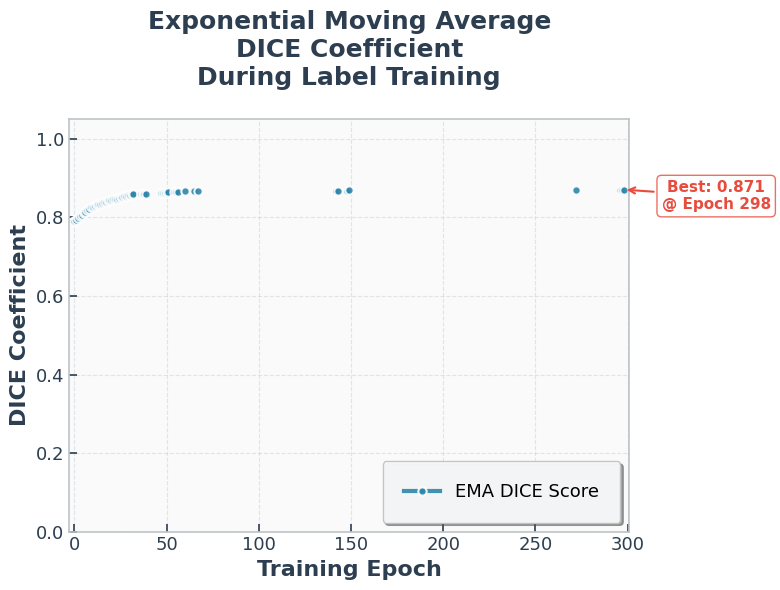

In [15]:
# Create figure with enhanced styling
fig, ax = plt.subplots(figsize=(8, 6))

# Plot EMA DICE with professional styling
ax.plot(df["epoch"], df["EMA_DICE"], color='#2E86AB', linewidth=3, marker='o', 
        markersize=6, label='EMA DICE Score', alpha=0.9, 
        markeredgecolor='white', markeredgewidth=1.5, markerfacecolor='#2E86AB')

# Enhanced styling
ax.set_title("Exponential Moving Average\nDICE Coefficient\nDuring Label Training", 
             fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
ax.set_xlabel("Training Epoch", fontsize=16, fontweight='bold', color='#2c3e50')
ax.set_ylabel("DICE Coefficient", fontsize=16, fontweight='bold', color='#2c3e50')

# Professional legend
legend = ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, 
                   fancybox=True, borderpad=1.2)
legend.get_frame().set_facecolor('#f8f9fa')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('#bdc3c7')

# Enhanced tick styling
ax.tick_params(axis='both', which='major', labelsize=13, direction='in', 
               length=6, width=1.2, colors='#2c3e50')

# Grid and background improvements
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8, color='#bdc3c7')
ax.set_axisbelow(True)

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1.2)

# Set appropriate y-axis limits for DICE scores
ax.set_ylim(0, 1.05)

# Add margins for better visualization
ax.margins(x=0.01)

# Add annotation for best score (optional)
best_epoch = df.loc[df["EMA_DICE"].idxmax(), "epoch"]
best_score = df["EMA_DICE"].max()
ax.annotate(f'Best: {best_score:.3f}\n@ Epoch {best_epoch}', 
            xy=(best_epoch, best_score), xytext=(best_epoch + 50, best_score - 0.05),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
            fontsize=11, ha='center', color='#e74c3c', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='#e74c3c', alpha=0.8))

plt.tight_layout()

# Save with descriptive filename
fn = Path("../output/figures/nnunet_brats2017_501_ema_dice_fold0_whole_core_enhancing_plot.tiff")
plt.savefig(fn, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()